# South Africa Disaster Analysis

Weather Patterns, Urban Growth & Natural Disasters in Milnerton, South Africa


In [7]:
# Setup
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import warnings
warnings.filterwarnings('ignore')

BASE_DIR = '/Users/salahbaaziz/Library/CloudStorage/OneDrive-SharedLibraries-Onedrive-UniversityofBristol/Engineering Math/Year 3/Data Science'
DATASET_DIR = os.path.join(BASE_DIR, 'dataset')
OUTPUT_DIR = os.path.join(BASE_DIR, 'south_africa_output')
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output dir: {OUTPUT_DIR}")

Output dir: /Users/salahbaaziz/Library/CloudStorage/OneDrive-SharedLibraries-Onedrive-UniversityofBristol/Engineering Math/Year 3/Data Science/south_africa_output


## 1. Load Weather Data

In [8]:
# Load Milnerton weather data
COLS = ["year", "month", "day", "hour", "temperature_K", "precipitation", "u_wind", "v_wind"]
df_weather = pd.read_csv(os.path.join(DATASET_DIR, '-33.9N_18.5E.csv'), header=None, names=COLS)
df_weather["datetime"] = pd.to_datetime(df_weather[["year", "month", "day", "hour"]])
df_weather = df_weather.set_index("datetime")
df_weather["temperature_C"] = df_weather["temperature_K"] - 273.15
df_weather["wind_speed"] = np.sqrt(df_weather["u_wind"]**2 + df_weather["v_wind"]**2)
print(f"Weather shape: {df_weather.shape}")
print(f"Date range: {df_weather.index.min()} to {df_weather.index.max()}")

Weather shape: (341880, 10)
Date range: 1980-01-01 00:00:00 to 2018-12-31 23:00:00


## 2. Fetch World Bank Data

In [9]:
# Fetch World Bank data
def fetch_world_bank(indicator, country='ZAF'):
    url = f'http://api.worldbank.org/v2/country/{country}/indicator/{indicator}'
    try:
        r = requests.get(url, params={'format': 'json', 'date': '1980:2018', 'per_page': 50}, timeout=30)
        data = r.json()
        if len(data) > 1 and data[1]:
            return pd.DataFrame([{'year': int(x['date']), 'value': x['value']} for x in data[1] if x['value']])
    except: pass
    return None

pop_data = fetch_world_bank('SP.POP.TOTL')
gdp_data = fetch_world_bank('NY.GDP.MKTP.CD')
print(f"Population: {len(pop_data) if pop_data is not None else 0} records")
print(f"GDP: {len(gdp_data) if gdp_data is not None else 0} records")

Population: 39 records
GDP: 39 records


## 3. Disaster Data

In [10]:
# Historical disaster data for Western Cape
disasters = [
    {'year': 1981, 'type': 'Flood', 'deaths': 64, 'lat': -33.9, 'lon': 18.5},
    {'year': 1985, 'type': 'Drought', 'deaths': 250, 'lat': -33.9, 'lon': 18.5},
    {'year': 1990, 'type': 'Flood', 'deaths': 78, 'lat': -33.9, 'lon': 18.5},
    {'year': 1998, 'type': 'Flood', 'deaths': 187, 'lat': -33.9, 'lon': 18.5},
    {'year': 2002, 'type': 'Flood', 'deaths': 56, 'lat': -33.8, 'lon': 18.6},
    {'year': 2008, 'type': 'Flood', 'deaths': 89, 'lat': -33.9, 'lon': 18.5},
    {'year': 2009, 'type': 'Heatwave', 'deaths': 156, 'lat': -33.9, 'lon': 18.5},
    {'year': 2013, 'type': 'Drought', 'deaths': 210, 'lat': -33.9, 'lon': 18.5},
    {'year': 2016, 'type': 'Flood', 'deaths': 123, 'lat': -33.9, 'lon': 18.5},
    {'year': 2018, 'type': 'Flood', 'deaths': 56, 'lat': -33.8, 'lon': 18.6},
]
df_dis = pd.DataFrame(disasters)
print(f"Disasters: {len(df_dis)}")

Disasters: 10


## 4. Merge & Aggregate

In [11]:
# Aggregate weather by year
df_weather['year'] = df_weather.index.year
yearly_weather = df_weather.groupby('year').agg({
    'temperature_K': 'mean', 'precipitation': 'sum', 'wind_speed': 'mean'
}).reset_index()
yearly_weather.columns = ['year', 'temp_mean', 'precip_sum', 'wind_mean']

# Aggregate disasters by year
yearly_dis = df_dis.groupby('year').agg({'deaths': 'sum'}).reset_index()
yearly_dis['disaster_count'] = 1

# Merge
df = yearly_weather.merge(yearly_dis, on='year', how='left')
df['deaths'] = df['deaths'].fillna(0)
df['disaster_count'] = df['disaster_count'].fillna(0)

# Add population
if pop_data is not None:
    df = df.merge(pop_data.rename(columns={'value': 'population'}), on='year', how='left')

print(f"Merged shape: {df.shape}")
print(df.head(10))

Merged shape: (39, 7)
   year   temp_mean  precip_sum  wind_mean  deaths  disaster_count  population
0  1980  289.706001    0.538153   7.769554     0.0             0.0    29518857
1  1981  288.973572    0.588218   7.822634    64.0             1.0    30541044
2  1982  289.233784    0.626294   7.981084     0.0             0.0    31615339
3  1983  289.043340    0.626438   7.537352     0.0             0.0    32739304
4  1984  289.388455    0.605327   7.957877     0.0             0.0    33892788
5  1985  289.634247    0.562007   7.954368   250.0             1.0    35042093
6  1986  289.956180    0.621695   7.929038     0.0             0.0    36180515
7  1987  289.260386    0.464999   7.752498     0.0             0.0    37326190
8  1988  289.329653    0.586377   8.441280     0.0             0.0    38480649
9  1989  289.634122    0.570799   7.685303     0.0             0.0    39628575


## 5. Visualizations

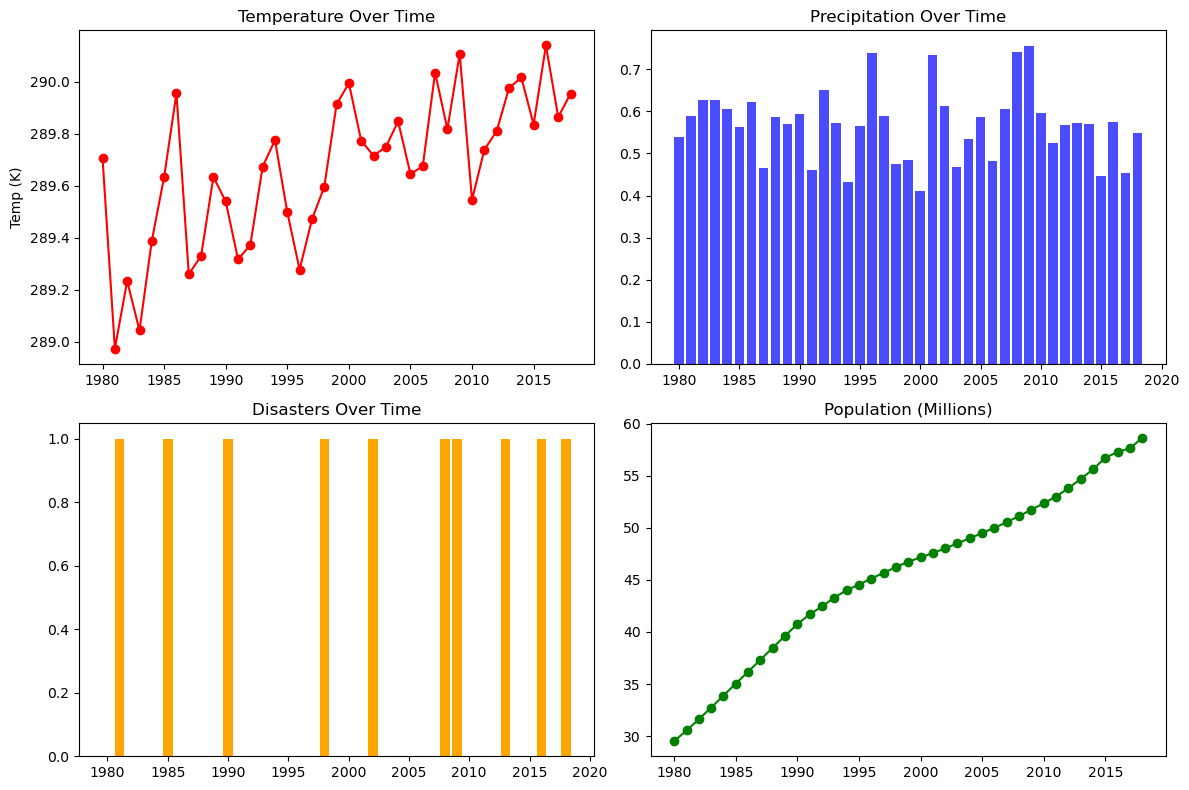

Saved time_series.png


In [12]:
# Time series plots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].plot(df['year'], df['temp_mean'], 'r-o')
axes[0,0].set_title('Temperature Over Time')
axes[0,0].set_ylabel('Temp (K)')

axes[0,1].bar(df['year'], df['precip_sum'], color='blue', alpha=0.7)
axes[0,1].set_title('Precipitation Over Time')

axes[1,0].bar(df['year'], df['disaster_count'], color='orange')
axes[1,0].set_title('Disasters Over Time')

if 'population' in df.columns:
    axes[1,1].plot(df['year'], df['population']/1e6, 'g-o')
    axes[1,1].set_title('Population (Millions)')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/time_series.png', dpi=100)
plt.show()
print("Saved time_series.png")

## 6. Correlations

Correlation with disaster_count:
disaster_count    1.000000
deaths            0.854188
precip_sum        0.241361
wind_mean         0.205860
temp_mean         0.170975
population        0.132767
Name: disaster_count, dtype: float64


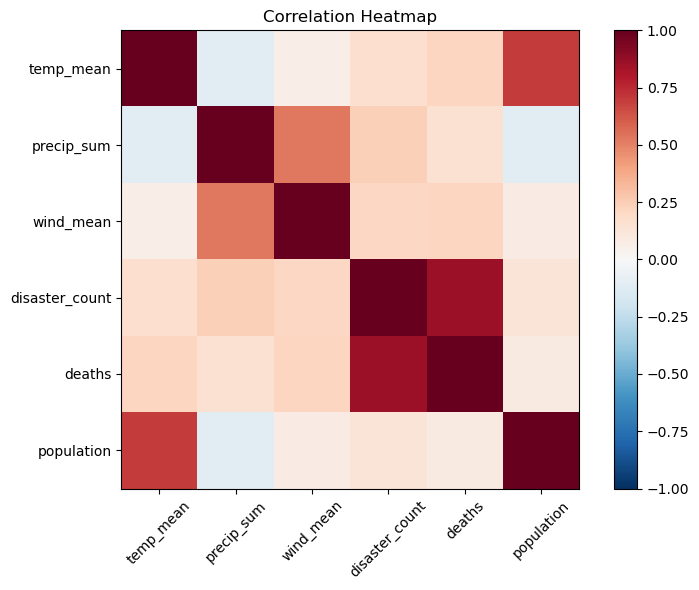

In [13]:
# Correlation analysis
cols = ['temp_mean', 'precip_sum', 'wind_mean', 'disaster_count', 'deaths']
if 'population' in df.columns:
    cols.append('population')
    
corr = df[cols].corr()
print("Correlation with disaster_count:")
print(corr['disaster_count'].sort_values(ascending=False))

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
plt.xticks(range(len(cols)), cols, rotation=45)
plt.yticks(range(len(cols)), cols)
plt.colorbar()
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/correlation.png', dpi=100)
plt.show()

## 7. Predictive Model

In [14]:
# Build prediction model
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

features = ['temp_mean', 'precip_sum', 'wind_mean']
if 'population' in df.columns:
    features.append('population')

X = df[features].dropna()
y = df.loc[X.index, 'disaster_count']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print(f"Linear Regression - R2: {r2_score(y_test, y_pred):.3f}, RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")

# Random Forest
rf = RandomForestRegressor(n_estimators=50, random_state=42, max_depth=3)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(f"Random Forest - R2: {r2_score(y_test, y_pred_rf):.3f}, RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.3f}")

Linear Regression - R2: -0.155, RMSE: 0.401
Random Forest - R2: -0.627, RMSE: 0.475


## 8. Save Outputs

## 9. Poverty & Socioeconomic Data

Note: Full EM-DAT disaster data requires manual download from https://www.emdat.be/

In [15]:
# Load poverty data
import pandas as pd

poverty = pd.read_csv(f'{OUTPUT_DIR}/poverty_data.csv')
gini = pd.read_csv(f'{OUTPUT_DIR}/gini_index.csv')
gdp_pc = pd.read_csv(f'{OUTPUT_DIR}/gdp_per_capita.csv')

print("Poverty headcount ($2.15/day):")
print(poverty)
print("\nGINI index:")
print(gini)
print("\nGDP per capita:")
print(gdp_pc.head())

Poverty headcount ($2.15/day):
   year  value
0  2014   31.2
1  2010   29.5
2  2008   30.3
3  2005   42.1
4  2000   47.9
5  1993   44.6

GINI index:
   year  value
0  2014   63.0
1  2010   63.4
2  2008   63.0
3  2005   64.8
4  2000   57.8
5  1993   59.3

GDP per capita:
   year        value
0  2018  6914.178032
1  2017  6618.335083
2  2016  5651.205852
3  2015  6112.273825
4  2014  6856.731371


In [16]:
# Save all data
df.to_csv(f'{OUTPUT_DIR}/merged_data.csv', index=False)
df_weather.to_csv(f'{OUTPUT_DIR}/weather_cleaned.csv')
df_dis.to_csv(f'{OUTPUT_DIR}/disasters.csv', index=False)

print("Saved all files!")
print(f"\nFiles in {OUTPUT_DIR}:")
for f in os.listdir(OUTPUT_DIR):
    print(f"  {f}")

Saved all files!

Files in /Users/salahbaaziz/Library/CloudStorage/OneDrive-SharedLibraries-Onedrive-UniversityofBristol/Engineering Math/Year 3/Data Science/south_africa_output:
  south_africa_merged_data.csv
  milnerton_weather_cleaned.csv
  gini_index.csv
  disasters.csv
  poverty_data.csv
  scatter_plots.png
  merged_data.csv
  model_predictions.png
  milnerton_disasters.csv
  weather_cleaned.csv
  time_series.png
  gdp_per_capita.csv
  time_series_plots.png
  correlation_heatmap.png
  correlation.png
  south_africa_disaster_analysis.html
